# Test 9: Coefficient Ablation for sin(a·x) + w·tanh(b·x)

**Гипотеза:** Коэффициенты a=8, w=0.5, b=4 в функции активации sin(a·x)+w·tanh(b·x) не являются единственным оптимальным набором. Систематическая абляция каждого коэффициента выявит зависимость дисперсии, мёртвых нейронов и качества реконструкции от параметров функции.

**План:**
- Эксперимент 1: Частота sin — `a` ∈ {2, 4, 6, **8**, 10, 12, 16}, w=0.5, b=4
- Эксперимент 2: Вес tanh — `w` ∈ {0.0, 0.1, 0.25, **0.5**, 0.75, 1.0}, a=8, b=4
- Эксперимент 3: Масштаб tanh — `b` ∈ {1, 2, **4**, 8, 12, 16}, a=8, w=0.5
- N=10 прогонов на каждую комбинацию
- Датасет: Logistic map 2000 train / 200 val / 500 test
- Метрики: variance, dead neurons, val_loss, sparsity
- Текущее значение выделено жирным (**bold**) — это контроль

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from scipy import stats
import json
from datetime import datetime

print(f"TF version: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

/Users/savenkovviktor/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TF version: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k

    def call(self, inputs, training=None):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(
            tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1
        )
        return inputs * mask

    def get_config(self):
        config = super().get_config()
        config.update({"k": self.k})
        return config


def make_chaos_activation(a=8.0, w=0.5, b=4.0):
    """Create chaos activation with given coefficients."""
    @tf.function
    def activation(x):
        return tf.sin(a * x) + w * tf.tanh(b * x)
    return activation


def build_ksparse_ae(a=8.0, w=0.5, b=4.0,
                     image_size=(28, 28), latent_dim=128, k_active=32):
    """Build K-Sparse AE with parameterized chaos activation."""
    act = make_chaos_activation(a, w, b)

    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)
    x = layers.Dense(256)(x)
    x = layers.Activation(act)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(latent_dim, name='latent_pre')(x)
    x = layers.Activation(act)(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_img, latent, name='encoder')

    x = layers.Dense(256)(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(act)(x)
    x = layers.Dropout(0.1)(x)
    decoded = layers.Dense(np.prod(image_size), activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


def analyze_latent(encoder, images, threshold=1e-6):
    latents = encoder.predict(images, verbose=0)
    variance_per_dim = np.var(latents, axis=0)
    dead_mask = np.all(np.abs(latents) < threshold, axis=0)
    zero_mask = np.abs(latents) < threshold
    return {
        'mean_variance': float(np.mean(variance_per_dim)),
        'dead_neurons': int(np.sum(dead_mask)),
        'total_neurons': latents.shape[1],
        'sparsity': float(np.mean(zero_mask)),
    }


print("Core components ready.")

Core components ready.


In [ ]:
def logistic_map(x, r=3.99):
    return r * x * (1 - x)


def generate_logistic_dataset(num_images, image_size=28, r=3.99):
    dataset = []
    for _ in range(num_images):
        x = np.random.rand()
        seq = []
        for _ in range(image_size * image_size):
            x = logistic_map(x, r)
            seq.append(x)
        dataset.append(np.array(seq).reshape(image_size, image_size))
    return np.array(dataset)[..., np.newaxis].astype('float32')


# Generate datasets (same as 6.2v2)
np.random.seed(42)
train_images = generate_logistic_dataset(2000)
np.random.seed(123)
val_images = generate_logistic_dataset(200)
np.random.seed(999)
test_images = generate_logistic_dataset(500)

print(f"Train: {train_images.shape}")
print(f"Val:   {val_images.shape}")
print(f"Test:  {test_images.shape}")

Train: (2000, 28, 28, 1)
Val:   (200, 28, 28, 1)
Test:  (500, 28, 28, 1)


In [ ]:
NUM_RUNS = 10
EPOCHS = 10
BATCH_SIZE = 64
LATENT_DIM = 128
K_ACTIVE = 32


def run_experiment(a, w, b, label):
    """Run N=10 independent trainings with given coefficients."""
    runs = []
    for run in range(NUM_RUNS):
        np.random.seed(run)
        tf.random.set_seed(run)

        ae, enc = build_ksparse_ae(
            a=a, w=w, b=b,
            latent_dim=LATENT_DIM, k_active=K_ACTIVE
        )
        history = ae.fit(
            train_images, train_images,
            epochs=EPOCHS, batch_size=BATCH_SIZE,
            validation_data=(val_images, val_images),
            verbose=0
        )
        s = analyze_latent(enc, test_images)
        s['val_loss'] = float(history.history['val_loss'][-1])
        runs.append(s)
        print(f"  {label} run {run+1}/{NUM_RUNS}: "
              f"var={s['mean_variance']:.4f}, "
              f"dead={s['dead_neurons']:>3d}/128, "
              f"loss={s['val_loss']:.4f}")

        del ae, enc
        keras.backend.clear_session()

    return runs


print(f"Config: N={NUM_RUNS} runs, {EPOCHS} epochs, "
      f"batch={BATCH_SIZE}, latent={LATENT_DIM}, K={K_ACTIVE}")

Config: N=10 runs, 10 epochs, batch=64, latent=128, K=32


## Experiment 1: Sin frequency `a` in sin(a·x) + 0.5·tanh(4·x)

In [ ]:
A_VALUES = [2, 4, 6, 8, 10, 12, 16]
A_CONTROL = 8  # current value

results_a = {}

for a_val in A_VALUES:
    tag = '(control)' if a_val == A_CONTROL else ''
    print(f"\n{'='*60}")
    print(f"a = {a_val} {tag}")
    print(f"{'='*60}")
    results_a[a_val] = run_experiment(
        a=float(a_val), w=0.5, b=4.0,
        label=f"a={a_val}"
    )

print("\nExperiment 1 done.")


a = 2 


2026-02-28 14:30:50.218316: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-02-28 14:30:50.218369: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-02-28 14:30:50.218374: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-02-28 14:30:50.218427: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-28 14:30:50.218443: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-02-28 14:30:50.624288: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  a=2 run 1/10: var=0.4451, dead=  0/128, loss=0.1185
  a=2 run 2/10: var=0.4340, dead=  0/128, loss=0.1183
  a=2 run 3/10: var=0.4371, dead=  0/128, loss=0.1186
  a=2 run 4/10: var=0.4533, dead=  0/128, loss=0.1184
  a=2 run 5/10: var=0.4350, dead=  0/128, loss=0.1186
  a=2 run 6/10: var=0.4409, dead=  0/128, loss=0.1184
  a=2 run 7/10: var=0.4350, dead=  0/128, loss=0.1184
  a=2 run 8/10: var=0.4427, dead=  0/128, loss=0.1183
  a=2 run 9/10: var=0.4410, dead=  0/128, loss=0.1183
  a=2 run 10/10: var=0.4292, dead=  0/128, loss=0.1184

a = 4 
  a=4 run 1/10: var=0.4593, dead=  0/128, loss=0.1180
  a=4 run 2/10: var=0.4606, dead=  0/128, loss=0.1182
  a=4 run 3/10: var=0.4592, dead=  0/128, loss=0.1181
  a=4 run 4/10: var=0.4557, dead=  0/128, loss=0.1180
  a=4 run 5/10: var=0.4604, dead=  0/128, loss=0.1180
  a=4 run 6/10: var=0.4596, dead=  0/128, loss=0.1181
  a=4 run 7/10: var=0.4592, dead=  0/128, loss=0.1181
  a=4 run 8/10: var=0.4601, dead=  0/128, loss=0.1180
  a=4 run 9/10: var

## Experiment 2: Tanh weight `w` in sin(8·x) + w·tanh(4·x)

In [ ]:
W_VALUES = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]
W_CONTROL = 0.5

results_w = {}

for w_val in W_VALUES:
    tag = '(control)' if w_val == W_CONTROL else ''
    print(f"\n{'='*60}")
    print(f"w = {w_val} {tag}")
    print(f"{'='*60}")
    results_w[w_val] = run_experiment(
        a=8.0, w=float(w_val), b=4.0,
        label=f"w={w_val}"
    )

print("\nExperiment 2 done.")


w = 0.0 
  w=0.0 run 1/10: var=0.2365, dead=  0/128, loss=0.1178
  w=0.0 run 2/10: var=0.2364, dead=  0/128, loss=0.1178
  w=0.0 run 3/10: var=0.2361, dead=  0/128, loss=0.1177
  w=0.0 run 4/10: var=0.2363, dead=  0/128, loss=0.1178
  w=0.0 run 5/10: var=0.2361, dead=  0/128, loss=0.1178
  w=0.0 run 6/10: var=0.2364, dead=  0/128, loss=0.1176
  w=0.0 run 7/10: var=0.2358, dead=  0/128, loss=0.1177
  w=0.0 run 8/10: var=0.2364, dead=  0/128, loss=0.1178
  w=0.0 run 9/10: var=0.2364, dead=  0/128, loss=0.1179
  w=0.0 run 10/10: var=0.2359, dead=  0/128, loss=0.1178

w = 0.1 
  w=0.1 run 1/10: var=0.2537, dead=  0/128, loss=0.1179
  w=0.1 run 2/10: var=0.2546, dead=  0/128, loss=0.1179
  w=0.1 run 3/10: var=0.2546, dead=  0/128, loss=0.1177
  w=0.1 run 4/10: var=0.2536, dead=  0/128, loss=0.1179
  w=0.1 run 5/10: var=0.2541, dead=  0/128, loss=0.1179
  w=0.1 run 6/10: var=0.2546, dead=  0/128, loss=0.1178
  w=0.1 run 7/10: var=0.2543, dead=  0/128, loss=0.1177
  w=0.1 run 8/10: var=0.254

## Experiment 3: Tanh scale `b` in sin(8·x) + 0.5·tanh(b·x)

In [ ]:
B_VALUES = [1, 2, 4, 8, 12, 16]
B_CONTROL = 4

results_b = {}

for b_val in B_VALUES:
    tag = '(control)' if b_val == B_CONTROL else ''
    print(f"\n{'='*60}")
    print(f"b = {b_val} {tag}")
    print(f"{'='*60}")
    results_b[b_val] = run_experiment(
        a=8.0, w=0.5, b=float(b_val),
        label=f"b={b_val}"
    )

print("\nExperiment 3 done.")


b = 1 
  b=1 run 1/10: var=0.3331, dead=  0/128, loss=0.1179
  b=1 run 2/10: var=0.3303, dead=  0/128, loss=0.1180
  b=1 run 3/10: var=0.3322, dead=  0/128, loss=0.1177
  b=1 run 4/10: var=0.3316, dead=  0/128, loss=0.1179
  b=1 run 5/10: var=0.3306, dead=  0/128, loss=0.1179
  b=1 run 6/10: var=0.3306, dead=  0/128, loss=0.1179
  b=1 run 7/10: var=0.3312, dead=  0/128, loss=0.1179
  b=1 run 8/10: var=0.3301, dead=  0/128, loss=0.1178
  b=1 run 9/10: var=0.3328, dead=  0/128, loss=0.1179
  b=1 run 10/10: var=0.3325, dead=  0/128, loss=0.1179

b = 2 
  b=2 run 1/10: var=0.3815, dead=  0/128, loss=0.1180
  b=2 run 2/10: var=0.3791, dead=  0/128, loss=0.1179
  b=2 run 3/10: var=0.3756, dead=  0/128, loss=0.1179
  b=2 run 4/10: var=0.3792, dead=  0/128, loss=0.1180
  b=2 run 5/10: var=0.3757, dead=  0/128, loss=0.1179
  b=2 run 6/10: var=0.3805, dead=  0/128, loss=0.1180
  b=2 run 7/10: var=0.3815, dead=  0/128, loss=0.1179
  b=2 run 8/10: var=0.3801, dead=  0/128, loss=0.1181
  b=2 run 9

In [ ]:
def summarize(results_dict, param_name, control_value):
    """Print table and return summary for one ablation."""
    print(f"\n{'='*80}")
    print(f"Results: {param_name} ablation (N={NUM_RUNS} runs)")
    print(f"{'='*80}")
    print(f"  {param_name:>6} | {'Variance':>16} | {'Dead Neurons':>14} | "
          f"{'Sparsity':>10} | {'Val Loss':>14} | {'p-value':>8}")
    print('-' * 90)

    summary = {}
    control_vars = [r['mean_variance'] for r in results_dict[control_value]]

    for param_val in sorted(results_dict.keys()):
        runs = results_dict[param_val]
        v = [r['mean_variance'] for r in runs]
        d = [r['dead_neurons'] for r in runs]
        sp = [r['sparsity'] for r in runs]
        l = [r['val_loss'] for r in runs]

        if param_val != control_value:
            _, p_val = stats.ttest_ind(v, control_vars, equal_var=False)
        else:
            p_val = 1.0

        row = {
            'var_mean': np.mean(v), 'var_std': np.std(v),
            'dead_mean': np.mean(d), 'dead_std': np.std(d),
            'sparsity_mean': np.mean(sp),
            'loss_mean': np.mean(l), 'loss_std': np.std(l),
            'p_value': p_val,
        }
        summary[param_val] = row

        marker = ' ◄' if param_val == control_value else ''
        sig = '' if param_val == control_value else (
            ' *' if p_val < 0.05 else ' ns'
        )
        print(f"  {param_val:>6} | "
              f"{row['var_mean']:.4f} ± {row['var_std']:.4f} | "
              f"{row['dead_mean']:>5.1f} ± {row['dead_std']:.1f} | "
              f"{row['sparsity_mean']:>8.1%} | "
              f"{row['loss_mean']:.4f} ± {row['loss_std']:.4f} | "
              f"{p_val:>8.4f}{sig}{marker}")

    return summary


print("Helper ready.")

Helper ready.


In [ ]:
summary_a = summarize(results_a, 'a', A_CONTROL)
summary_w = summarize(results_w, 'w', W_CONTROL)
summary_b = summarize(results_b, 'b', B_CONTROL)


Results: a ablation (N=10 runs)
       a |         Variance |   Dead Neurons |   Sparsity |       Val Loss |  p-value
------------------------------------------------------------------------------------------
       2 | 0.4393 ± 0.0065 |   0.0 ± 0.0 |    75.0% | 0.1184 ± 0.0001 |   0.0000 *
       4 | 0.4592 ± 0.0014 |   0.0 ± 0.0 |    75.0% | 0.1181 ± 0.0001 |   0.0000 *
       6 | 0.4297 ± 0.0020 |   0.0 ± 0.0 |    75.0% | 0.1181 ± 0.0000 |   0.0000 *
       8 | 0.4187 ± 0.0019 |   0.0 ± 0.0 |    75.0% | 0.1180 ± 0.0001 |   1.0000 ◄
      10 | 0.4128 ± 0.0015 |   0.0 ± 0.0 |    75.0% | 0.1180 ± 0.0001 |   0.0000 *
      12 | 0.4106 ± 0.0027 |   0.0 ± 0.0 |    75.0% | 0.1180 ± 0.0001 |   0.0000 *
      16 | 0.4132 ± 0.0029 |   0.0 ± 0.0 |    75.0% | 0.1180 ± 0.0001 |   0.0003 *

Results: w ablation (N=10 runs)
       w |         Variance |   Dead Neurons |   Sparsity |       Val Loss |  p-value
------------------------------------------------------------------------------------------

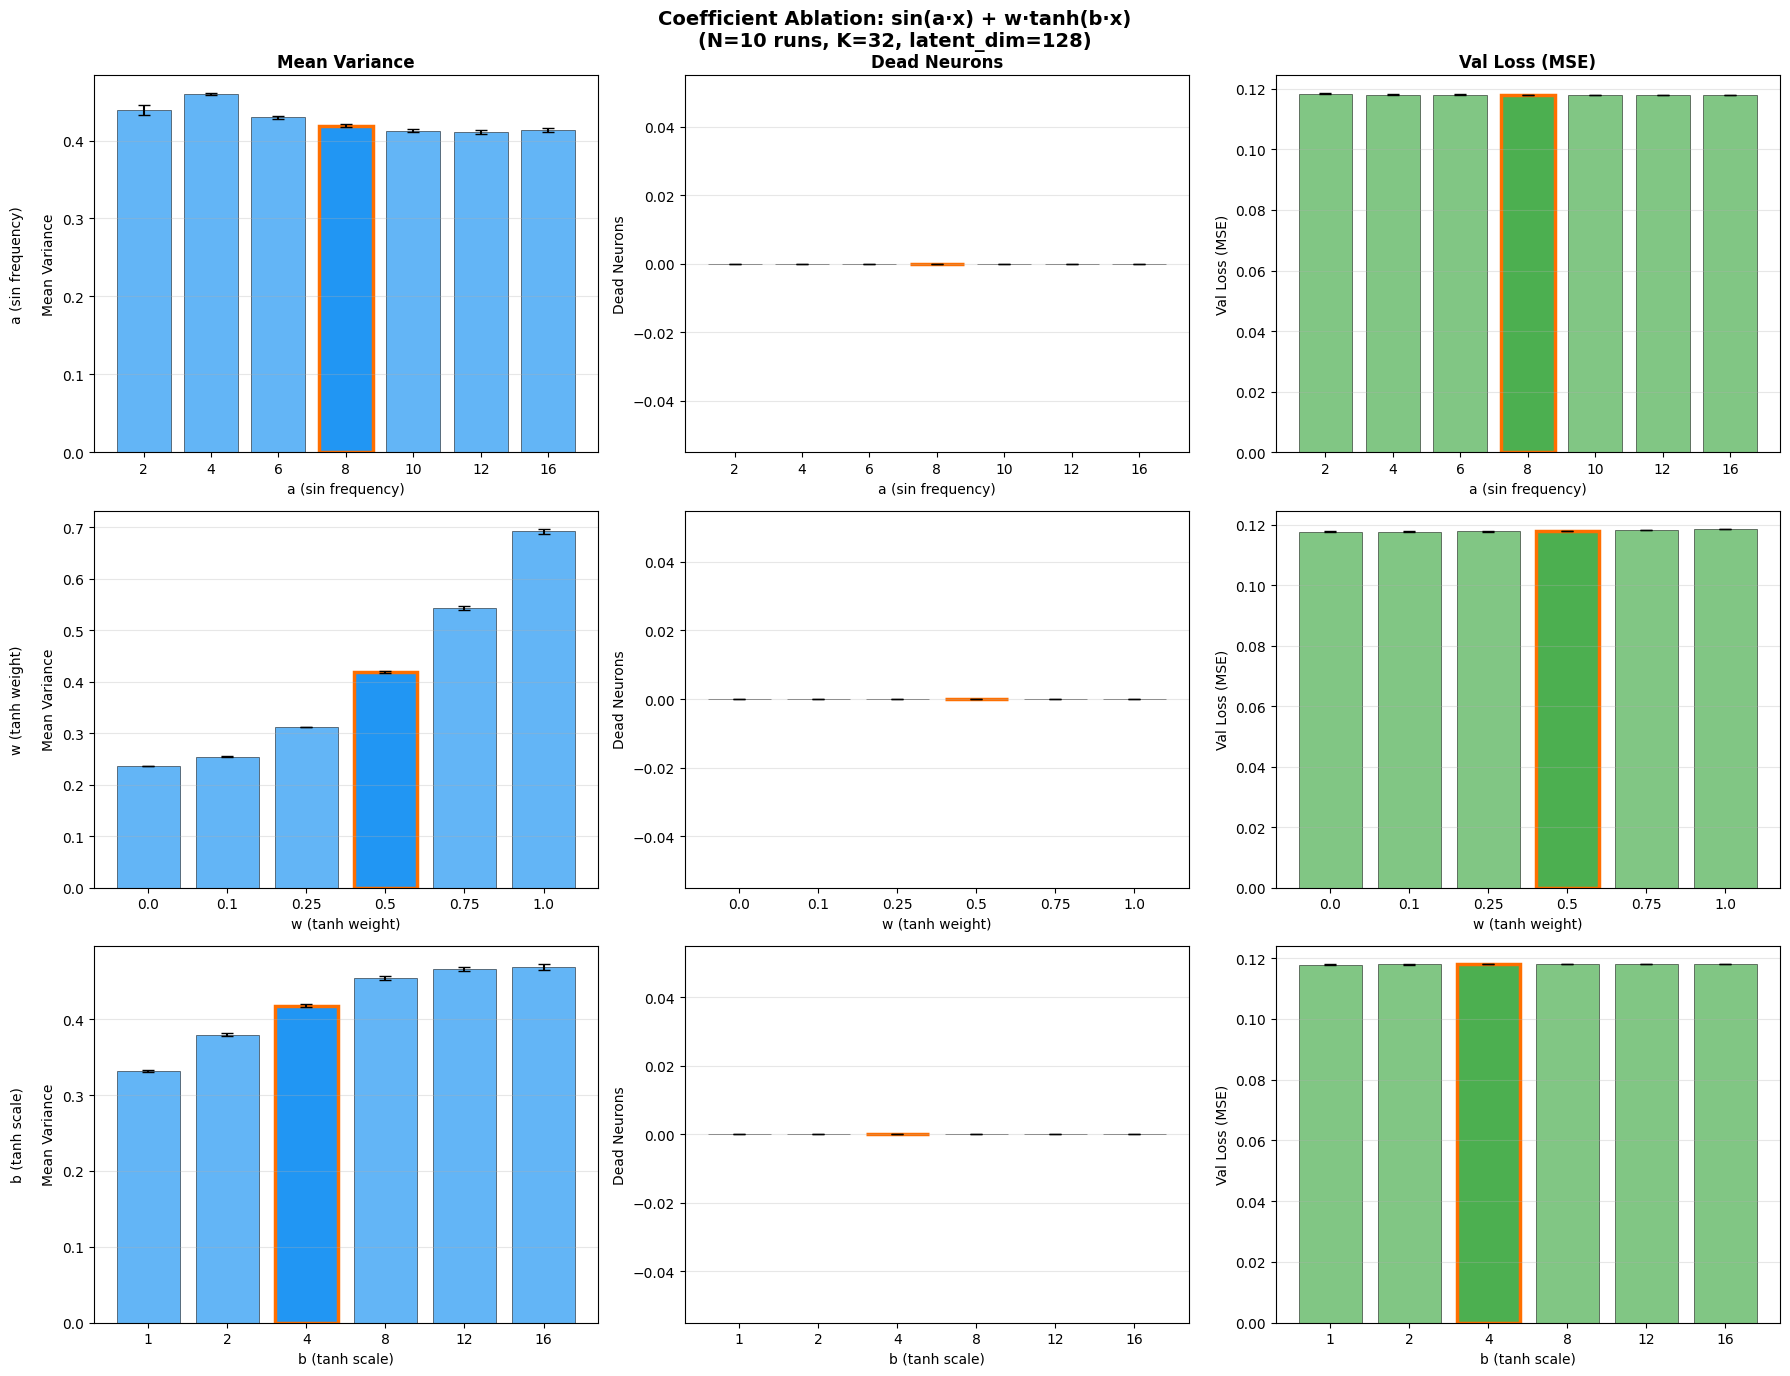

Saved: images/coefficient_ablation.png


In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

experiments = [
    ('a (sin frequency)', A_VALUES, A_CONTROL, summary_a),
    ('w (tanh weight)',   W_VALUES, W_CONTROL, summary_w),
    ('b (tanh scale)',    B_VALUES, B_CONTROL, summary_b),
]

metric_configs = [
    ('var_mean', 'var_std', 'Mean Variance', '#2196F3'),
    ('dead_mean', 'dead_std', 'Dead Neurons', '#F44336'),
    ('loss_mean', 'loss_std', 'Val Loss (MSE)', '#4CAF50'),
]

for row, (param_label, values, control, summary) in enumerate(experiments):
    for col, (mean_key, std_key, ylabel, color) in enumerate(metric_configs):
        ax = axes[row, col]
        means = [summary[v][mean_key] for v in values]
        stds = [summary[v][std_key] for v in values]

        x_pos = np.arange(len(values))
        bars = ax.bar(x_pos, means, yerr=stds, capsize=4,
                      color=color, alpha=0.7, edgecolor='black', linewidth=0.5)

        # Highlight control value
        ctrl_idx = values.index(control)
        bars[ctrl_idx].set_edgecolor('#FF6F00')
        bars[ctrl_idx].set_linewidth(2.5)
        bars[ctrl_idx].set_alpha(1.0)

        ax.set_xticks(x_pos)
        ax.set_xticklabels([str(v) for v in values])
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3, axis='y')

        if row == 0:
            ax.set_title(ylabel, fontsize=12, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f"{param_label}\n\n{ylabel}", fontsize=10)

        ax.set_xlabel(param_label)

plt.suptitle(
    f'Coefficient Ablation: sin(a·x) + w·tanh(b·x)\n'
    f'(N={NUM_RUNS} runs, K={K_ACTIVE}, latent_dim={LATENT_DIM})',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../images/coefficient_ablation.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: images/coefficient_ablation.png")

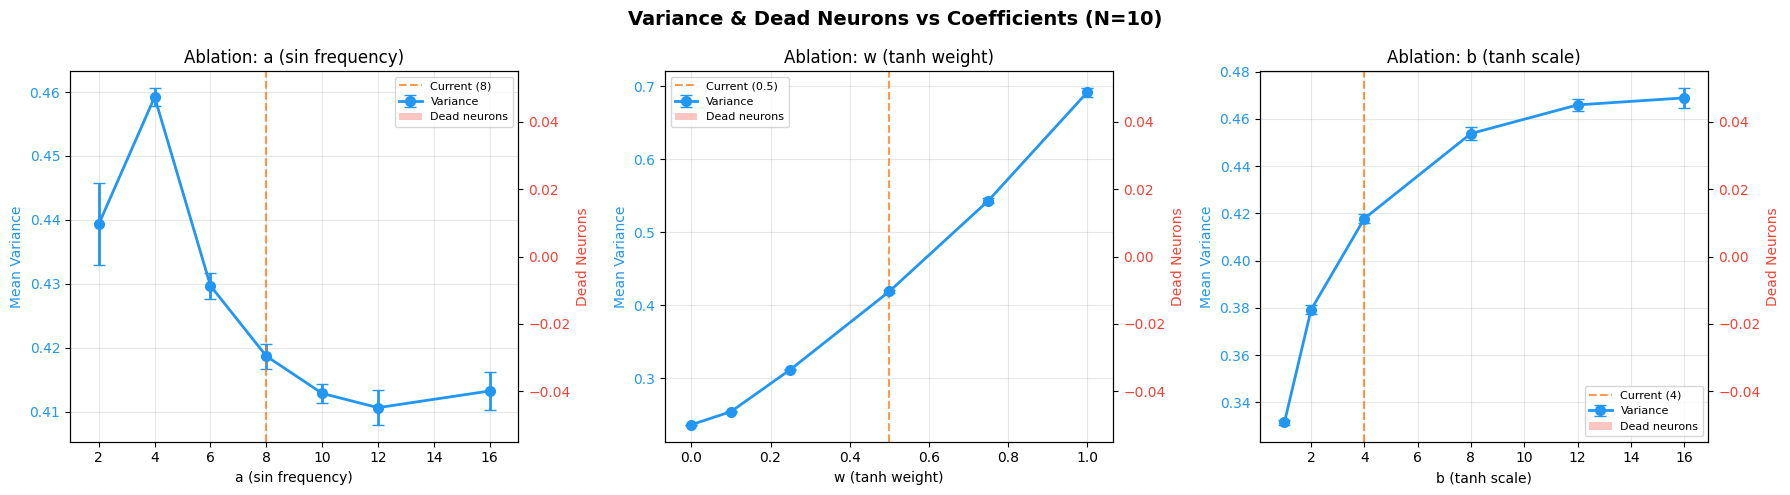

Saved: images/coefficient_ablation_lines.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (param_label, values, control, summary) in zip(axes, experiments):
    x = [float(v) for v in values]
    var_m = [summary[v]['var_mean'] for v in values]
    var_s = [summary[v]['var_std'] for v in values]
    dead_m = [summary[v]['dead_mean'] for v in values]

    # Variance line
    ax.errorbar(x, var_m, yerr=var_s, marker='o', color='#2196F3',
                capsize=4, linewidth=2, markersize=7, label='Variance')

    # Control marker
    ctrl_idx = values.index(control)
    ax.axvline(x=float(control), color='#FF6F00', linestyle='--',
               alpha=0.7, label=f'Current ({control})')

    # Dead neurons on secondary axis
    ax2 = ax.twinx()
    ax2.bar(x, dead_m, width=(x[1]-x[0])*0.3 if len(x) > 1 else 0.5,
            color='#F44336', alpha=0.3, label='Dead neurons')
    ax2.set_ylabel('Dead Neurons', color='#F44336')
    ax2.tick_params(axis='y', labelcolor='#F44336')

    ax.set_xlabel(param_label)
    ax.set_ylabel('Mean Variance', color='#2196F3')
    ax.tick_params(axis='y', labelcolor='#2196F3')
    ax.set_title(f'Ablation: {param_label}')
    ax.grid(True, alpha=0.3)

    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=8)

plt.suptitle(
    f'Variance & Dead Neurons vs Coefficients (N={NUM_RUNS})',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../images/coefficient_ablation_lines.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: images/coefficient_ablation_lines.png")

In [ ]:
def results_to_serializable(results_dict):
    return {str(k): v for k, v in results_dict.items()}


def summary_to_serializable(summary_dict):
    return {str(k): v for k, v in summary_dict.items()}


save_data = {
    'experiment': 'coefficient_ablation',
    'timestamp': datetime.now().isoformat(),
    'config': {
        'num_runs': NUM_RUNS,
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'latent_dim': LATENT_DIM,
        'k_active': K_ACTIVE,
        'dataset': 'logistic_map',
        'train_size': 2000,
        'val_size': 200,
        'test_size': 500,
    },
    'experiments': {
        'sin_frequency_a': {
            'values': A_VALUES,
            'control': A_CONTROL,
            'fixed': {'w': 0.5, 'b': 4.0},
            'raw_results': results_to_serializable(results_a),
            'summary': summary_to_serializable(summary_a),
        },
        'tanh_weight_w': {
            'values': W_VALUES,
            'control': W_CONTROL,
            'fixed': {'a': 8.0, 'b': 4.0},
            'raw_results': results_to_serializable(results_w),
            'summary': summary_to_serializable(summary_w),
        },
        'tanh_scale_b': {
            'values': B_VALUES,
            'control': B_CONTROL,
            'fixed': {'a': 8.0, 'w': 0.5},
            'raw_results': results_to_serializable(results_b),
            'summary': summary_to_serializable(summary_b),
        },
    },
}

json_path = f'../jsons/coefficient_ablation_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
with open(json_path, 'w') as f:
    json.dump(save_data, f, indent=2, default=str)
print(f"Results saved: {json_path}")

Results saved: ../jsons/coefficient_ablation_20260228_145845.json
